In [52]:
import torch

class StockPriceSimulator:
    def __init__(self, sample_num = 10000, quarter_num = 16, mu = 0.0, sigma = 0.04697492584088936*np.sqrt(3*21), initial_price = 30, init_cash = 650, cash_per_quarter = 100,):
        self.sample_num = sample_num
        self.quarter_num = quarter_num
        self.mu = mu
        self.sigma = sigma
        self.initial_price = initial_price
        self.cash_vector = torch.zeros(self.sample_num, self.quarter_num)
        self.cash_vector[:, :8] = cash_per_quarter
        self.cash_vector[:, 8:] = cash_per_quarter * 1.5
        self.base_vector = torch.zeros(self.sample_num, self.quarter_num)
        self.base_vector[:, :] = 250. / 4
        self.stock_vector = torch.zeros(self.sample_num, self.quarter_num)
        self.stock_price_vector = torch.zeros(self.sample_num, self.quarter_num)
        self.stock_price_vector_init()
        self.stock_price_purchase_plan()
        self.stock_price_init_plan(init_cash)
    
    def stock_price_vector_init(self):
        """
        This is a simulator for the stock price random work assumption.

        initial stock price
        """
        self.stock_price_vector[:, 0] = self.initial_price
        for i in range(1, self.quarter_num):
            self.stock_price_vector[:, i] = self.stock_price_vector[:, i-1] * ((1. + self.mu) + self.sigma * torch.randn(self.sample_num))
        return

    def stock_price_purchase_plan(self):
        """
        This is a simulator for the stock price random work assumption.
        the cash vector is the investment amount of each quarter.
        the stock price vector is the stock price of each quarter.
        at each quarter, the investor will purchase the stock number of cash / stock price, and allocate to 12 quarters to release in the stock vector.
        """
        # cash_vector: shape [sample_num, quarter_num]
        # For each quarter, calculate how many stocks are purchased: cash / stock price
        # Allocate each purchase to be released over the next 12 quarters (vesting)
        # We'll build a stock_vector of shape [sample_num, quarter_num] to track vested stock at each quarter

        for q in range(self.quarter_num):
            # Number of stocks purchased at quarter q
            stocks_purchased = self.cash_vector[:, q] / self.stock_price_vector[:, q]
            # Distribute these stocks equally over the next 12 quarters (or until the end)
            for offset in range(12):
                release_q = q + offset
                if release_q < self.quarter_num:
                    self.stock_vector[:, release_q] += stocks_purchased / 12.
        
    def stock_price_init_plan(self, cash):
        """
        This is a simulator for the stock price random work assumption.

        initial stock price
        """
        self.stock_vector[:, :4] += (cash / self.stock_price_vector[:, 0].unsqueeze(1) * 0.5 / 4)
        self.stock_vector[:, 4:8] += (cash / self.stock_price_vector[:, 0].unsqueeze(1) * 0.33 / 4)
        self.stock_vector[:, 8:12] += (cash / self.stock_price_vector[:, 0].unsqueeze(1) * 0.17 / 4)
        

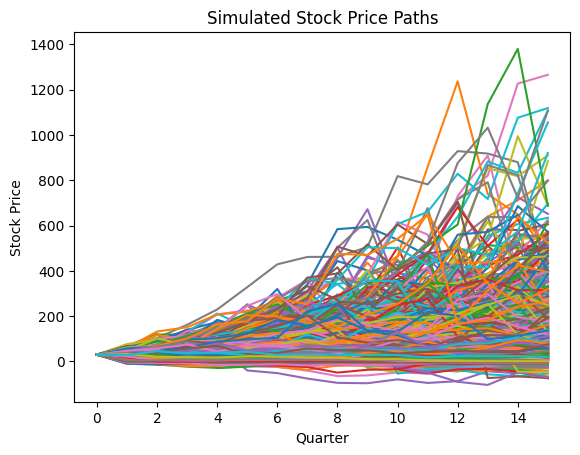

Last Quarter Price Distribution:
Mean: 29.09
Std: 65.46
Min: -74.22
Max: 1265.34


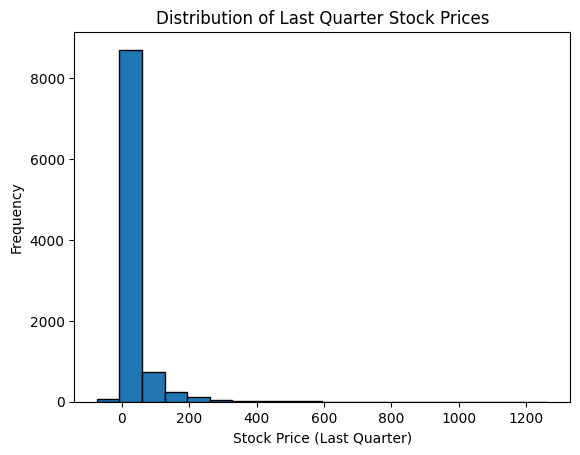

In [53]:
# draw picture
import matplotlib.pyplot as plt
import numpy as np
sps = StockPriceSimulator()
price_series_vector = sps.stock_price_vector

# Measure the distribution of the last quarter
last_quarter_prices = price_series_vector[:, -1].numpy()

# Plot all price series
plt.figure()
for i in range(price_series_vector.shape[0]):
    plt.plot(price_series_vector[i].numpy())
plt.xlabel('Quarter')
plt.ylabel('Stock Price')
plt.title('Simulated Stock Price Paths')
plt.show()

# Print basic statistics
mean_price = last_quarter_prices.mean()
std_price = last_quarter_prices.std()
min_price = last_quarter_prices.min()
max_price = last_quarter_prices.max()

print(f"Last Quarter Price Distribution:")
print(f"Mean: {mean_price:.2f}")
print(f"Std: {std_price:.2f}")
print(f"Min: {min_price:.2f}")
print(f"Max: {max_price:.2f}")

# Plot histogram of the last quarter prices
plt.figure()
plt.hist(last_quarter_prices, bins=20, edgecolor='black')
plt.xlabel('Stock Price (Last Quarter)')
plt.ylabel('Frequency')
plt.title('Distribution of Last Quarter Stock Prices')
plt.show()


Last Quarter Price Distribution:
Mean: 2815.42
Std: 2775.04
Min: -1837.73
Max: 52896.19


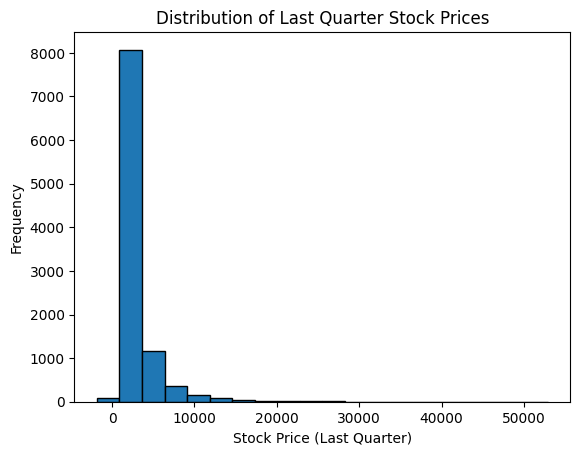

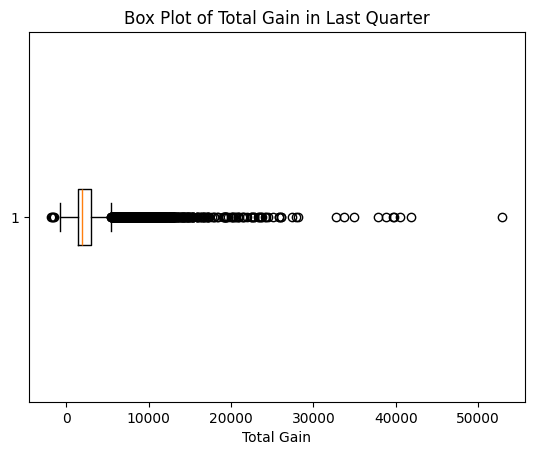

In [54]:
# Measure the distribution of the last quarter
total_gain = (sps.base_vector[:].sum(dim=1) + sps.stock_vector.sum(dim=1) * sps.stock_price_vector[:, -1]).numpy()


# Print basic statistics
mean_price = total_gain.mean()
std_price = total_gain.std()
min_price = total_gain.min()
max_price = total_gain.max()

print(f"Last Quarter Price Distribution:")
print(f"Mean: {mean_price:.2f}")
print(f"Std: {std_price:.2f}")
print(f"Min: {min_price:.2f}")
print(f"Max: {max_price:.2f}")

# Plot histogram of the last quarter prices
plt.figure()
plt.hist(total_gain, bins=20, edgecolor='black')
plt.xlabel('Stock Price (Last Quarter)')
plt.ylabel('Frequency')
plt.title('Distribution of Last Quarter Stock Prices')
plt.show()

# Draw a box plot of the total_gain distribution
plt.figure()
plt.boxplot(total_gain, vert=False)
plt.xlabel('Total Gain')
plt.title('Box Plot of Total Gain in Last Quarter')
plt.show()

In [ ]:

# Download SNAP historical close prices
snap = yf.Ticker("SNAP")
snap_close = snap.history(period="max")['Close']

# Display the first few rows of the closing prices
print(snap_close.head())


snap.history(period="10y")  # You can specify period, e.g., "1y", "5y", etc.


snap_hist = yf.Ticker("SNAP").history(period="max")  # You can specify period, e.g., "1y", "5y", etc.

# Display the first few rows of the historical price data
print(snap_hist.head())



Date
2017-03-02 00:00:00-05:00    24.480000
2017-03-03 00:00:00-05:00    27.090000
2017-03-06 00:00:00-05:00    23.770000
2017-03-07 00:00:00-05:00    21.440001
2017-03-08 00:00:00-05:00    22.809999
Name: Close, dtype: float64
                                Open       High        Low      Close  \
Date                                                                    
2017-03-02 00:00:00-05:00  24.000000  26.049999  23.500000  24.480000   
2017-03-03 00:00:00-05:00  26.389999  29.440001  26.059999  27.090000   
2017-03-06 00:00:00-05:00  28.170000  28.250000  23.770000  23.770000   
2017-03-07 00:00:00-05:00  22.209999  22.500000  20.639999  21.440001   
2017-03-08 00:00:00-05:00  22.030001  23.430000  21.309999  22.809999   

                              Volume  Dividends  Stock Splits  
Date                                                           
2017-03-02 00:00:00-05:00  217048900        0.0           0.0  
2017-03-03 00:00:00-05:00  148166400        0.0           0.0  
2017

In [29]:
import numpy as np
import yfinance as yf

from sklearn.linear_model import LinearRegression

def estimate_gbm_params_per_month(ticker='TICKER', freq=1, trading_days_per_freq=1):
    """
    Estimate GBM parameters (mu, intercept, std) per month for a given ticker's historical price DataFrame.
    hist_df: DataFrame with at least a 'Close' column.
    ticker: string, ticker symbol (for printout).
    Returns: mu_per_month, mu_intercept, std_per_month
    """
    hist_df = yf.Ticker(ticker=ticker).history(period="10y")
    close_prices = hist_df['Close'].dropna()
    # Calculate daily log returns
    log_returns = np.log(close_prices / close_prices.shift(freq)).dropna()
    X = np.arange(len(log_returns)).reshape(-1, 1)
    y = log_returns.values.reshape(-1, 1)
    reg = LinearRegression().fit(X, y)
    mu_daily = reg.coef_[0, 0]
    mu_intercept = reg.intercept_[0]
    residuals = y - reg.predict(X)
    std_daily = np.std(residuals)
    # Convert daily mu and std to per month (assuming 21 trading days per month)
    mu_per_freq = mu_daily * trading_days_per_freq
    std_per_freq = std_daily * np.sqrt(trading_days_per_freq)
    print(f"[{ticker}] Estimated mu per month (drift): {mu_per_freq}")
    print(f"[{ticker}] Estimated intercept: {mu_intercept}")
    print(f"[{ticker}] Estimated std per month (volatility): {std_per_freq}")
    return mu_per_freq, mu_intercept, std_per_freq

# Example usage:
estimate_gbm_params_per_month(ticker='SNAP')
estimate_gbm_params_per_month(ticker='PINS')
estimate_gbm_params_per_month(ticker='META')


[SNAP] Estimated mu per month (drift): -4.084761820666416e-07
[SNAP] Estimated intercept: -9.567619025239131e-05
[SNAP] Estimated std per month (volatility): 0.04697492584088936
[PINS] Estimated mu per month (drift): -1.2480243804898755e-06
[PINS] Estimated intercept: 0.0009870083711996942
[PINS] Estimated std per month (volatility): 0.039472889780662934
[META] Estimated mu per month (drift): 3.8168061604556377e-08
[META] Estimated intercept: 0.0007090895956730242
[META] Estimated std per month (volatility): 0.024304162140958933


(3.8168061604556377e-08, 0.0007090895956730242, 0.024304162140958933)